# Mass ordering and the $\theta_{23}$ octant

Two open questions, and how they show up in the probabilities. `globaldefs` carries the NuFit best fit for both orderings, so both are available without typing any numbers.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import earth


def h_vacuum(ordering="NO", s23=None, dcp=None):
    """Vacuum Hamiltonian for either ordering, with overrides."""
    if ordering == "NO":
        s12, s23d, s13 = gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF
        dcpd, d21, d31 = gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF
    else:
        s12, s23d, s13 = gd.S12_IO_BF, gd.S23_IO_BF, gd.S13_IO_BF
        dcpd, d21, d31 = gd.DCP_IO_BF, gd.D21_IO_BF, gd.D31_IO_BF
    return hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        s12, s23 if s23 is not None else s23d, s13,
        dcp if dcp is not None else dcpd, d21, d31)


print("normal   : Dm31 = %+.3e eV^2" % gd.D31_NO_BF)
print("inverted : Dm31 = %+.3e eV^2" % gd.D31_IO_BF)

normal   : Dm31 = +2.525e-03 eV^2
inverted : Dm31 = -2.438e-03 eV^2


## In vacuum the ordering barely shows

The sign of $\Delta m^2_{31}$ enters the vacuum probabilities only through the small solar and CP-violating terms.

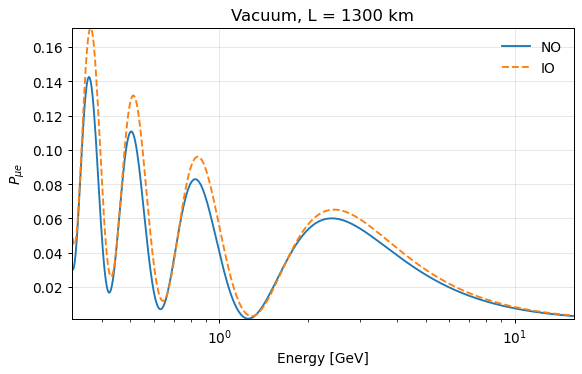

In [3]:
E_gev = np.logspace(-0.5, 1.2, 500)
L = 1300.0*KM

fig, ax = plt.subplots()
for ordering, ls in (("NO", "-"), ("IO", "--")):
    p = oscprob3nu.probabilities_3nu(
        np.asarray(h_vacuum(ordering))/(E_gev[:, None, None]*GEV), L)
    ax.semilogx(E_gev, p[:, 3], ls, label=ordering)
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Vacuum, L = 1300 km")
ax.legend()
plt.show()

## Matter is what separates them

The matter potential enters with a definite sign, so it enhances the resonance for one ordering and suppresses it for the other. This is the whole basis of the experimental programme.

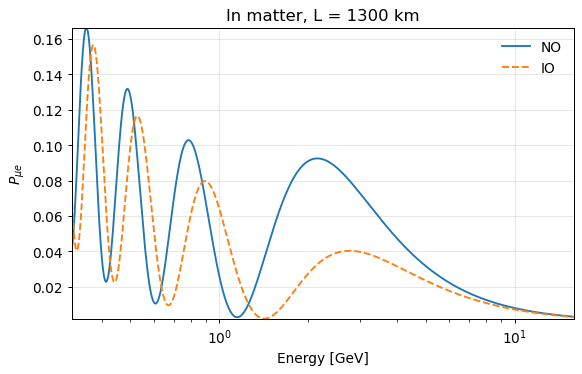

In [4]:
fig, ax = plt.subplots()
for ordering, ls in (("NO", "-"), ("IO", "--")):
    H = hamiltonians3nu.hamiltonian_3nu_matter(
        h_vacuum(ordering), E_gev*GEV, gd.VCC_EARTH_CRUST)
    ax.semilogx(E_gev, oscprob3nu.probabilities_3nu(H, L)[:, 3],
                ls, label=ordering)
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("In matter, L = 1300 km")
ax.legend()
plt.show()

## Through the Earth the separation is larger still

A trajectory through the mantle sees much more matter than a 1300 km chord through the crust.

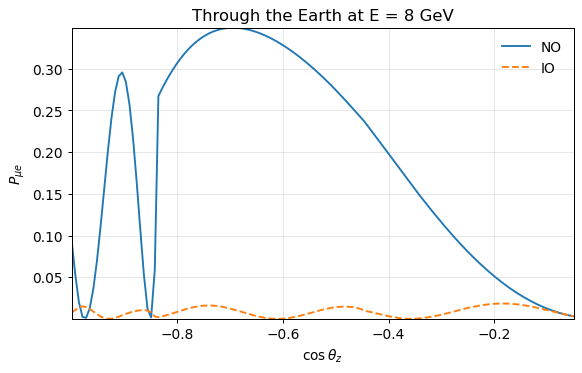

In [5]:
costhz = np.linspace(-0.999, -0.05, 140)
E_fixed = 8.0*GEV

fig, ax = plt.subplots()
for ordering, ls in (("NO", "-"), ("IO", "--")):
    hv = h_vacuum(ordering)
    p = [earth.probabilities_3nu_earth(
        hv, E_fixed, c, n_slabs_per_segment=5)[3] for c in costhz]
    ax.plot(costhz, p, ls, label=ordering)
ax.set_xlim(costhz[0], costhz[-1])
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Through the Earth at E = 8 GeV")
ax.legend()
plt.show()

## The octant

Disappearance depends on $\theta_{23}$ mainly through $\sin^2 2\theta_{23}$, which is symmetric about $\theta_{23} = \pi/4$. Two values either side of maximal are therefore nearly indistinguishable in $P_{\mu\mu}$ — the octant degeneracy.

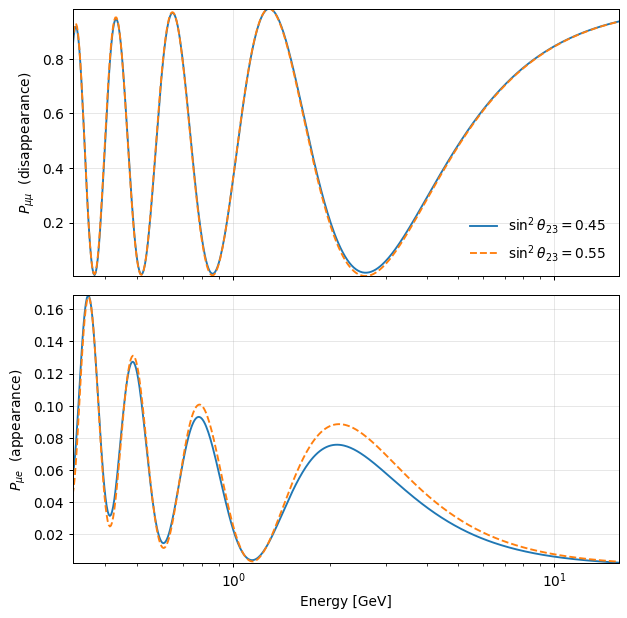

In [6]:
s23_lower = np.sqrt(0.45)      # below maximal
s23_upper = np.sqrt(0.55)      # above maximal

fig, axes = plt.subplots(2, 1, figsize=(7.2, 7.0), sharex=True)
for s23, ls, lab in ((s23_lower, "-", r"$\sin^2\theta_{23} = 0.45$"),
                     (s23_upper, "--", r"$\sin^2\theta_{23} = 0.55$")):
    H = hamiltonians3nu.hamiltonian_3nu_matter(
        h_vacuum("NO", s23=s23), E_gev*GEV, gd.VCC_EARTH_CRUST)
    p = oscprob3nu.probabilities_3nu(H, L)
    axes[0].semilogx(E_gev, p[:, 4], ls, label=lab)
    axes[1].semilogx(E_gev, p[:, 3], ls, label=lab)
axes[0].set_ylabel(r"$P_{\mu\mu}$  (disappearance)")
axes[1].set_ylabel(r"$P_{\mu e}$  (appearance)")
axes[1].set_xlabel("Energy [GeV]")
for ax in axes:
    ax.set_xlim(E_gev[0], E_gev[-1])
axes[0].legend()
fig.tight_layout()
plt.show()

Disappearance can hardly tell the two apart; appearance can, because it carries a factor of $\sin^2\theta_{23}$ rather than $\sin^2 2\theta_{23}$. That asymmetry is why resolving the octant needs the appearance channel.